# GRU Networks

## Start with the problem: keep useful history with fewer controls

Imagine a sensor reporting a machine's behavior every second. Some readings are routine, while a few indicate a meaningful change. A useful model needs a representation that remains stable during ordinary readings and changes when new evidence matters.

A vanilla recurrent neural network recomputes its hidden state with a nonlinear transform at every step. An LSTM adds a separate cell state and gates for retention, writing, and exposure. A **gated recurrent unit (GRU)** takes a more compact approach: it maintains one hidden state and learns how to blend that state with a proposed replacement.

This lesson explains the reset gate and update gate, derives a complete scalar transition, follows a changing state over time, and connects the representation to a loss. We will also distinguish two update-gate conventions so that an equation in the notes does not get confused with a framework's parameter labels.

Read [LSTM Networks](23_LSTM_Networks_Notes.ipynb) for the separate-cell design. The [code companion](24_GRU_Networks.ipynb) checks a simple blend, inspects GRU shapes, and trains a small order classifier. The examples are chosen for transparency, not benchmark performance.


## See the candidate and the blend as separate operations

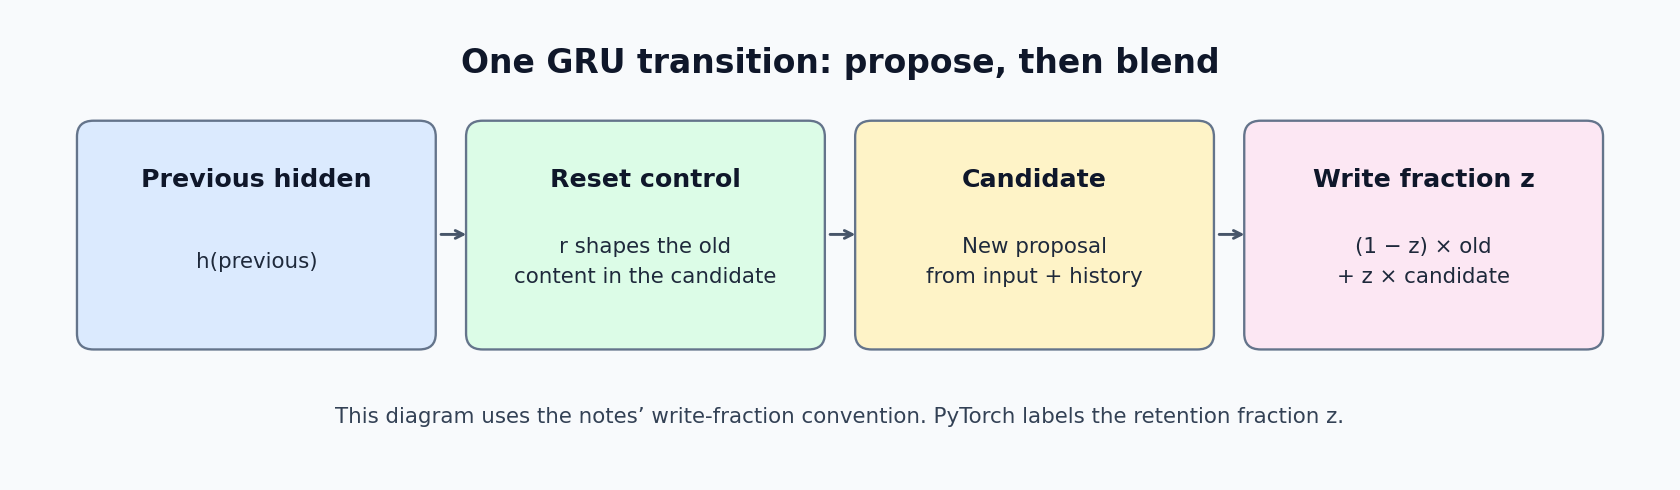

At time $t$, the GRU receives input $x_t$ and previous hidden state $h_{t-1}$. It computes a reset gate, an update gate, and a candidate state. Finally it mixes the old state with the candidate to obtain $h_t$.

There is no separate persistent cell $c_t$. The hidden state serves both as the carried representation and the state exposed to an output head. Removing the cell does not remove memory: memory is whatever useful information the hidden vector preserves across transitions.

> **Main idea:** first propose a new representation; then learn how much of it to write.

The reset gate and update gate operate at different places in this process. Reset changes the candidate calculation. Update changes the final mixture. Mixing up those roles makes it difficult to interpret the network's behavior.


## Give every symbol a concrete job

| Symbol | Meaning | Shape for one example |
| --- | --- | --- |
| $x_t$ | Current input features | $D$ |
| $h_{t-1}$ | Previous hidden representation | $H$ |
| $r_t$ | Reset gate | $H$ |
| $z_t$ | Write fraction in these notes | $H$ |
| $\tilde h_t$ | Candidate hidden representation | $H$ |
| $h_t$ | Updated hidden representation | $H$ |

The sigmoid function maps gate scores into $(0,1)$, while tanh maps candidate scores into $(-1,1)$. A gate value of 0.25 means “use one quarter” in the location where it multiplies a value. It is not a class probability or an instruction supplied by a person.

Each hidden coordinate can have its own reset and write values. A single transition might preserve one coordinate, revise another, and almost replace a third. These coordinates are learned numerical features; their meanings are not assigned in advance.

Zero initialization is common for independent examples. If states are carried between chunks, those chunks must represent a continuous history, and the training graph must be managed deliberately.


## Derive the reset-controlled candidate

A common mathematical formulation is:

$$r_t=\sigma(W_r x_t+U_r h_{t-1}+b_r),$$
$$z_t=\sigma(W_z x_t+U_z h_{t-1}+b_z),$$
$$\tilde h_t=\tanh(W_h x_t+U_h(r_t\odot h_{t-1})+b_h).$$

The input matrices $W$ have shape $H\times D$, recurrent matrices $U$ have shape $H\times H$, and biases have $H$ entries. The reset gate scales the previous hidden vector before its recurrent contribution to the candidate in this formulation.

If $r_t$ is near zero, the candidate relies less on the prior hidden content along that route. If it is near one, that content contributes more fully. Neither case specifies the candidate by itself: the current input, learned transforms, and bias still matter.

A low reset gate does **not** directly erase the carried hidden state. The old state remains available in the final blending operation. The update gate must also allow the candidate to replace it before the new state changes substantially.


## Read the update as a learned interpolation

These notes use the write-fraction convention:

$$h_t=(1-z_t)\odot h_{t-1}+z_t\odot\tilde h_t.$$

For each coordinate, the old-state and candidate weights add to one. Under this convention, small $z$ retains most of the old state and large $z$ writes most of the candidate.

| Write fraction $z$ | Old fraction $1-z$ | Behavior |
| --- | --- | --- |
| 0.01 | 0.99 | Mostly retain |
| 0.25 | 0.75 | Small revision |
| 0.50 | 0.50 | Equal blend |
| 0.90 | 0.10 | Mostly replace |

This convex blend lies between the old value and candidate for each coordinate. That does not mean the entire network is linear: the gates and candidate depend nonlinearly on the input and previous state.

With a zero initial state and tanh candidates, the hidden values remain within $[-1,1]$ under this standard update. A supplied initial state outside that interval changes this particular bound until its influence decays.


## Work the companion's scalar blend by hand

Start with $h_0=0.6$, selected candidate $\tilde h_1=-0.2$, and write fraction $z_1=0.25$:

$$h_1=(1-0.25)(0.6)+0.25(-0.2)=0.45-0.05=0.4.$$

| Part | Calculation | Contribution |
| --- | --- | --- |
| Old representation | $0.75\times0.6$ | $0.45$ |
| Candidate write | $0.25\times(-0.2)$ | $-0.05$ |
| Updated hidden state | $0.45-0.05$ | $0.40$ |

The candidate is negative, but the updated state remains positive because most of the old value is retained. A candidate is a proposal, not necessarily the final state.

The companion selects the candidate directly to isolate this interpolation. It does not derive that value from the built-in GRU's weights. To understand a full transition, we must also explain how inputs and reset control could produce the selected candidate.


## Construct a complete transition that produces that candidate

Choose scalar input $x_1=1$ and prior state $h_0=0.6$. For the reset gate, use $W_r=U_r=b_r=0$, giving $r_1=\sigma(0)=0.5$. For the write gate, use zero weights and bias $b_z=\ln(1/3)$, giving $z_1=0.25$.

For the candidate, choose $W_h=1$, $U_h=1$, and

$$b_h=\operatorname{atanh}(-0.2)-1.3\approx-1.502733.$$

The inverse tanh is used only to construct this teaching example. Then:

| Operation | Substitution | Result |
| --- | --- | --- |
| Reset old content | $0.5\times0.6$ | $0.3$ |
| Candidate affine score | $1(1)+1(0.3)-1.502733$ | $-0.202733$ |
| Candidate activation | $\tanh(-0.202733)$ | $-0.2$ |
| Final blend | $0.75(0.6)+0.25(-0.2)$ | $0.4$ |

This supplies every missing calculation. It is one possible parameter choice, not a unique explanation of the blend. Holding the input and candidate parameters fixed, a different reset gate changes the candidate; a different write gate changes how much of that candidate reaches the final state.


## Avoid the update-gate convention trap

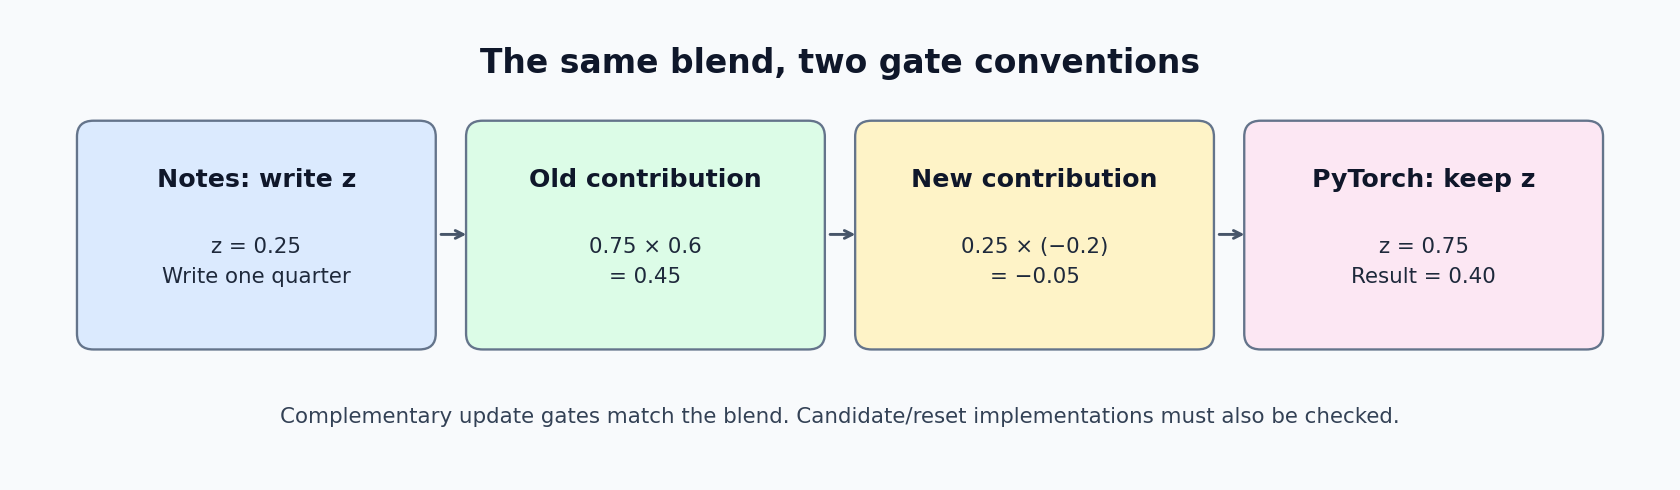

PyTorch labels the retention fraction $z$, using $h_t=z_t h_{t-1}+(1-z_t)n_t$. Thus the notes' write fraction 0.25 corresponds to PyTorch retention 0.75. PyTorch also applies the reset gate after the recurrent candidate transform: $n_t=\tanh(W_{in}x_t+b_{in}+r_t\odot(W_{hn}h_{t-1}+b_{hn}))$. See the [official GRU equations and implementation note](https://docs.pytorch.org/docs/stable/generated/torch.nn.GRU.html).

For vectors, $U(r\odot h)$ and $r\odot(Uh)$ generally differ: a matrix mixes coordinates, so moving a coordinatewise gate across it changes the calculation. Bias placement matters too. Complementing an update gate alone therefore does not make two candidate implementations identical.

The companion's manual scalar blend follows the notes' convention. Its built-in GRU example independently checks shapes and fitting behavior; it does not assert identical parameters between the two formulations.

> **Useful habit:** write down what a gate multiplies before deciding whether a large gate value means “keep” or “replace.”


## Watch the representation change across several steps

Choose the following gate outputs and candidates to illustrate several behaviors. Each row begins with the state produced by the row before it.

| Step | Previous $h$ | Write $z$ | Candidate | Old contribution | New contribution | Updated $h$ |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 0.6000 | 0.25 | -0.20 | 0.4500 | -0.0500 | 0.4000 |
| 2 | 0.4000 | 0.10 | 0.80 | 0.3600 | 0.0800 | 0.4400 |
| 3 | 0.4400 | 0.80 | -0.50 | 0.0880 | -0.4000 | -0.3120 |
| 4 | -0.3120 | 0.05 | 0.30 | -0.2964 | 0.0150 | -0.2814 |

Step 2 changes the state only slightly because the write fraction is small, even though the candidate is large and positive. Step 3 makes a substantial revision because the write fraction is large. Step 4 mostly retains that revised representation.

A GRU can therefore respond quickly at one step and remain stable at another. The table does not show learned event detection: its values are hand-selected. In a trained model, the gates must infer their behavior from data and the task loss.


## Turn a representation into a prediction and update

Use $h_1=0.4$ with a scalar binary head $q=vh_1+b$. Choose $v=2$ and $b=-0.1$, giving $q=0.7$ and $p=\sigma(0.7)\approx0.668188$.

For target one, the loss is $L=-\ln(p)\approx0.403186$. Its head-score derivative is $p-1\approx-0.331812$. Therefore:

$$\frac{\partial L}{\partial v}=(p-1)h_1\approx-0.132725,$$
$$\frac{\partial L}{\partial b}=p-1\approx-0.331812.$$

At learning rate 0.1, an SGD update changes the weight to approximately 2.013272 and bias to -0.066819. Holding $h_1$ fixed, the new score is approximately 0.738490, moving the prediction toward the correct class.

The gradient sent back into the hidden representation is $\partial L/\partial h_1=v(p-1)\approx-0.663624$, using the original head weight. Full training propagates it through the mixture, the candidate, the gates, and earlier recurrent steps. The output head and recurrence learn together; this example isolates the head so each number can be checked.


## Explain how the blend can preserve a gradient path

Holding candidate and gate outputs fixed, the direct derivative of $h_t$ with respect to $h_{t-1}$ is $1-z_t$ under the notes' convention. Repeated small write fractions can preserve this particular old-state path.

| Constant write fraction | Direct retention after 10 steps |
| --- | --- |
| 0.50 | $0.5^{10}\approx0.000977$ |
| 0.10 | $0.9^{10}\approx0.348678$ |
| 0.01 | $0.99^{10}\approx0.904382$ |

The full derivative also includes how the gates and candidate change with the prior state. This table isolates one route; it is not a complete Jacobian or a guarantee that training will find long-range dependencies.

A GRU still uses backpropagation through time. Detaching a carried state between chunks cuts earlier gradient paths while preserving its numerical value. Gradient clipping can limit large gradient norms, but it does not change which earlier computations remain connected to the loss.

Memory behavior and trainability should be measured on the actual dependency lengths of interest, rather than inferred only from the architecture name.


## Read the shapes returned by the companion

The companion's built-in GRU uses input size two and hidden size four. One sequence has three positions.

| Object | Shape | Meaning |
| --- | --- | --- |
| Input, batch first | $(1,3,2)$ | Batch, time, features |
| Output sequence | $(1,3,4)$ | Hidden vector at every position |
| Final hidden state | $(1,1,4)$ | Layer/direction, batch, hidden |

There is no returned cell state. For this one-layer, forward-only, unpadded example, the final hidden state equals the last output. A task head maps the hidden width to the prediction width: four hidden features might feed two class logits, one regression value, or a vocabulary-sized output.

The hidden width does not have to match the input width. The learned input matrices convert $D$ features into $H$ state coordinates. Sequence length is another dimension entirely: it determines how many times the transition is applied, not how many parameters the layer owns.


## Compare parameter counts with explicit assumptions

A GRU has three affine blocks: reset, update, and candidate. An LSTM has four: forget, input, candidate, and output. With one bias vector per block, a standard single layer has:

$$N_{GRU}=3H(D+H+1),\qquad N_{LSTM}=4H(D+H+1).$$

For $D=2$ and $H=8$, these are $3(8)(11)=264$ and $4(8)(11)=352$. These counts exclude the output head. They describe the stated mathematical parameterization; separate input and recurrent bias vectors add another bias per block.

| Design question | GRU | LSTM |
| --- | --- | --- |
| Persistent vectors | Hidden only | Hidden and cell |
| Candidate/history control | Reset gate | Gates around cell retention and writing |
| Separate exposure gate | No | Yes |
| Affine blocks | Three | Four |
| Accuracy or latency guarantee | None | None |

A smaller parameter count can be useful, but does not prove lower measured latency or better generalization. Compare actual implementations at the batch size, hidden width, and sequence length you intend to use.


## Handle padding and choose a useful summary

A batch may contain valid lengths $[3,5]$ while storing five positions for both examples. For a forward-only GRU, gathering `outputs[batch_index, length - 1]` reads the last valid representation. Taking the final stored position can instead read a state altered by padding.

Masked mean pooling is another summary:

$$\bar h_b=\frac{\sum_t m_{b,t}h_{b,t}}{\sum_t m_{b,t}},$$

where $m_{b,t}=1$ for a valid observation and zero for padding. The denominator counts valid positions, not the maximum stored length. Each sequence must have at least one valid observation for this expression to be defined.

Packing can keep padded steps out of recurrent computation. A mask applied only to the loss does not stop padding from changing hidden states. For bidirectional recurrence, valid-length handling matters in both directions because reverse processing can encounter padding before valid observations.

Sequence labeling uses a head at every valid position. Whole-sequence classification uses a summary. Forecasting uses only history available before the target. Decide which task you are solving before selecting the readout.


## Inspect the tiny order-classifier demonstration

The code companion constructs length-six sequences with two event channels. One channel marks a marker and the other a distractor. The two classes contain the same counts but differ in which event occurs first.

A GRU with eight hidden units reads the sequence; a linear head produces two logits from the last output. Adam updates the recurrent and head parameters using cross-entropy. No padding is needed because every example has the same length.

The dataset repeats two fixed templates. High training accuracy confirms that this GRU classifier can fit those templates. It does not measure robustness to shifted positions, longer delays, unseen distractors, or a different sensor population.

To investigate memory, vary the gap between events and evaluate performance by gap length. To investigate generalization, hold out event patterns or sources. Keep the evaluation protocol comparable when testing a vanilla RNN or LSTM; changing both the data split and model makes the cause of a score difference unclear.


## Diagnose mistakes and choose the next experiment

| Mistake or symptom | Explanation | Next check |
| --- | --- | --- |
| Large update gate interpreted incorrectly | Gate conventions differ | Identify which term the gate multiplies |
| Manual and library states disagree | Reset placement or biases differ | Compare the complete candidate equations |
| Extra padding changes classification | Wrong final state or recurrence handling | Inspect lengths and readout indices |
| Good fit, poor unseen performance | Template reuse or weak split | Hold out independent patterns or sources |
| Earlier chunks never receive gradients | State was detached | Decide the intended truncation length |

A useful model choice depends on the data's structure and practical constraints. GRUs are reasonable compact recurrent baselines for event streams and sensor histories. LSTMs provide separate control over stored and exposed content. A fixed-window MLP can be sufficient when the useful history fits inside a known window.

Before making a recurrent layer wider, confirm that targets, masks, state resets, and preprocessing are correct. Those decisions directly determine what the training loss teaches the model.


## Practice the controls and summarize the lesson

1. With old state 0.8, candidate -0.4, and write fraction 0.25, what is the new state?
2. What is the complementary retention fraction for the same blend?
3. Does a reset gate near zero necessarily erase the carried state?
4. Why does a loss mask alone fail to prevent padding from changing a recurrent state?

**Answers.** The result is $0.75(0.8)+0.25(-0.4)=0.5$. The retention fraction is 0.75. A low reset gate changes the candidate's use of history, while the blend can still retain the old state. A loss mask excludes objective terms but does not skip the recurrent transitions over padded inputs.

**Remember:** a GRU proposes a new representation and learns how much to blend it into the old one. The reset gate shapes the proposal; the update gate controls the mixture. Always state which update convention is being used.

Continue with [Sequence Modeling](25_Sequence_Modeling_Notes.ipynb) to organize target timing, batching, forecasting, and evaluation.
